# Nearshoring en cifras: a dónde llega la inversión extranjera en México, 2006 a 2025

México encadena récords de inversión extranjera directa y el nearshoring se discute con titulares. Aquí se mira la serie completa de la Secretaría de Economía, veinte años por estado, país y tipo de inversión, para responder tres cosas: cuánto del récord es dinero nuevo, a qué estados llega y de qué países viene.

**Fuente:** Secretaría de Economía vía la API de datos.gob.mx, cifras actualizadas, consulta del 21 de septiembre de 2026 (ver `data/manifest.json`). El notebook 01 explica la descarga y la limpieza.

## 0. Una consulta, una gráfica

Una llamada a la API trae la IED por estado. El acumulado del cuarto trimestre es el flujo anual, así que no hace falta desacumular para comparar años.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_inline
import pandas as pd
import requests
from matplotlib import font_manager as fm

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = RAIZ / "data"
API = "https://www.datos.gob.mx/api/3/action"
SESION = requests.Session()
SESION.headers["User-Agent"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0 Safari/537.36"

PALETA = {
    "papel": "#050706", "panel": "#0B0F0D", "tinta": "#F3F1EC", "tenue": "#ACABA7", "leve": "#81817E",
    "filete": "#222321", "filete_fuerte": "#393A38", "acento": "#00DF81", "acento_hondo": "#00C271",
    "neutro": "#646561", "neutro_claro": "#9A9A96",
}
# Archivo (póster) para los títulos y IBM Plex Mono para el pie, si están instaladas; el cuerpo va en DejaVu Sans.
for archivo in ["NyxArchivo-VF.ttf", "NyxIBMPlexMono-Regular.ttf"]:
    ruta = Path.home() / "Library" / "Fonts" / archivo
    if ruta.exists():
        fm.fontManager.addfont(str(ruta))
INSTALADAS = {f.name for f in fm.fontManager.ttflist}
ARCHIVO = "Archivo" if "Archivo" in INSTALADAS else "DejaVu Sans"
MONO = "IBM Plex Mono" if "IBM Plex Mono" in INSTALADAS else "DejaVu Sans Mono"
plt.rcParams.update({
    "figure.facecolor": PALETA["papel"], "axes.facecolor": PALETA["papel"], "savefig.facecolor": PALETA["papel"],
    "text.color": PALETA["tinta"], "axes.labelcolor": PALETA["tenue"],
    "xtick.color": PALETA["tenue"], "ytick.color": PALETA["tenue"],
    "axes.edgecolor": PALETA["filete_fuerte"], "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.family": "DejaVu Sans", "font.size": 12, "axes.titlesize": 16, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 28,
    "figure.figsize": (12, 6.75), "figure.dpi": 100, "savefig.dpi": 150, "legend.frameon": False,
})


def leer(tabla: str) -> pd.DataFrame:
    """Lee una tabla del snapshot que dejó el notebook 01."""
    return pd.read_csv(DATA / f"{tabla}.csv")


def titulo(ax, texto, size=16):
    ax.set_title(texto, fontsize=size, fontfamily=ARCHIVO, fontweight="bold")


def pie(fig, texto="Fuente: Secretaría de Economía vía datos.gob.mx · cifras actualizadas · consulta 21 sep 2026"):
    fig.text(0.01, 0.005, texto, ha="left", va="bottom", fontsize=9, color=PALETA["leve"], fontfamily=MONO)

In [2]:
def ied_por_estado() -> pd.DataFrame:
    """IED anual por estado, en vivo desde la API; si falla, desde el snapshot."""
    try:
        recursos = SESION.get(f"{API}/package_show", params={"id": "inversion_extranjera_directa"}, timeout=30).json()["result"]["resources"]
        rid = next(r["id"] for r in recursos if r["url"].endswith("_act_ti_destino.csv"))
        res = SESION.get(f"{API}/datastore_search", params={"resource_id": rid, "limit": 32000}, timeout=60).json()["result"]
        df = pd.DataFrame(res["records"])
        df[["anio", "trimestre"]] = df["anio_trim"].str.split("-", expand=True).astype(int)
        df["ied_acumulado_mdd"] = pd.to_numeric(df["ied_mdd"], errors="coerce")
        origen = f"API en vivo · {res['total']:,} filas"
    except Exception as e:  # noqa: BLE001
        df = leer("act_ti_destino")
        origen = f"snapshot ({type(e).__name__})"
    anual = df[df.trimestre == 4][["entidad_federativa", "anio", "ied_acumulado_mdd"]]
    print(origen)
    return anual


anual = ied_por_estado()
anual.tail(3)

API en vivo · 2,640 filas


,entidad_federativa,anio,ied_acumulado_mdd
2631,Zacatecas,2023,620.046467
2635,Zacatecas,2024,134.428657
2639,Zacatecas,2025,97.539061


In [3]:
estados = anual[anual.entidad_federativa != "Total general"].pivot(index="entidad_federativa", columns="anio", values="ied_acumulado_mdd")
total = anual[anual.entidad_federativa == "Total general"].set_index("anio")["ied_acumulado_mdd"]
participacion = 100 * estados / total

ULTIMO = int(participacion.columns.max())
base = participacion.loc[:, 2015:2019].mean(axis=1).rename("2015-2019")
ultimo = participacion[ULTIMO].rename(str(ULTIMO))
comparacion = pd.concat([base, ultimo], axis=1).sort_values(str(ULTIMO), ascending=False)

def estados_para_80(col: pd.Series) -> int:
    acumulado = col.sort_values(ascending=False).cumsum()
    return int((acumulado < 80).sum() + 1)

n80 = participacion.apply(estados_para_80)
print(f"Estados que concentran el 80 % de la IED: {n80[ULTIMO]} en {ULTIMO}, "
      f"{n80.loc[2015:2019].mean():.0f} en promedio 2015-2019")
comparacion.head(10).round(1)

Estados que concentran el 80 % de la IED: 6 en 2025, 13 en promedio 2015-2019


,2015-2019,2025
entidad_federativa,,
Ciudad de México,19.1,52.9
Nuevo León,9.2,8.9
Estado de México,8.5,7.6
Baja California,4.3,4.6
Baja California Sur,1.4,4.1
Jalisco,5.5,3.4
Coahuila,5.9,3.2
Quintana Roo,1.4,2.7
Chihuahua,5.3,2.6


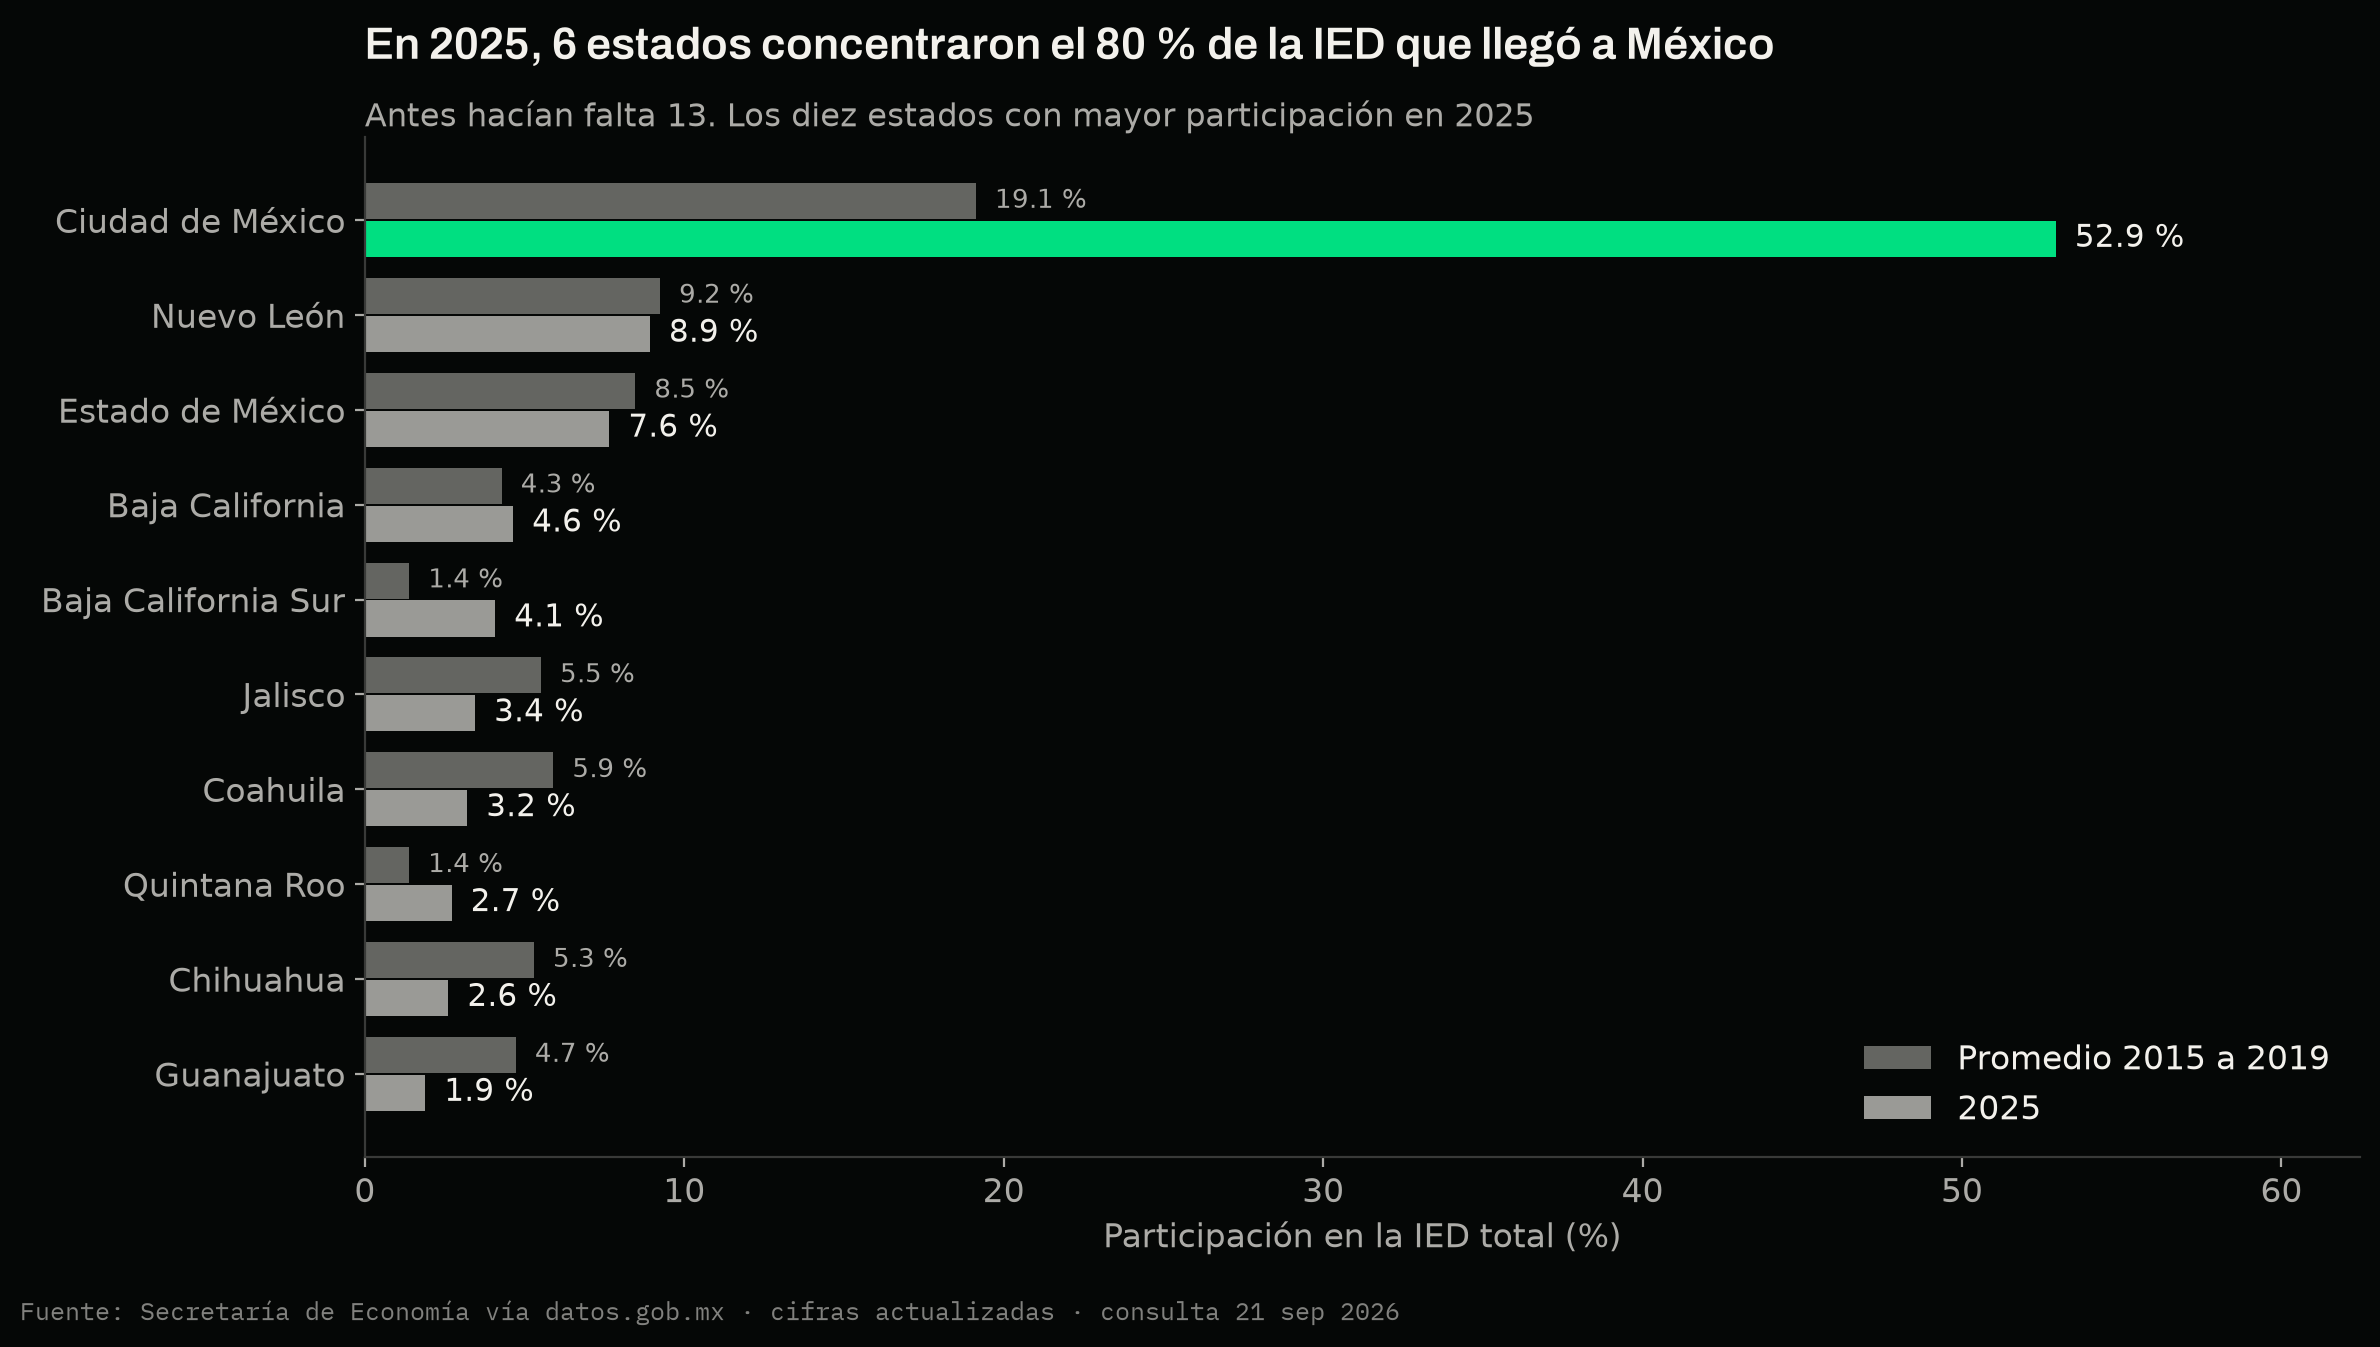

In [4]:
top = comparacion.head(10).iloc[::-1]
fig, ax = plt.subplots()
y = range(len(top))
ax.barh([i + 0.2 for i in y], top["2015-2019"], height=0.38, color=PALETA["neutro"], label="Promedio 2015 a 2019")
colores = [PALETA["acento"] if e == "Ciudad de México" else PALETA["neutro_claro"] for e in top.index]
ax.barh([i - 0.2 for i in y], top[str(ULTIMO)], height=0.38, color=colores, label=str(ULTIMO))
for i, (b, u) in enumerate(zip(top["2015-2019"], top[str(ULTIMO)])):
    ax.text(u + 0.6, i - 0.2, f"{u:.1f} %", va="center", fontsize=11, color=PALETA["tinta"])
    ax.text(b + 0.6, i + 0.2, f"{b:.1f} %", va="center", fontsize=9.5, color=PALETA["tenue"])
ax.set_yticks(list(y), top.index)
ax.set_xlim(0, top[str(ULTIMO)].max() * 1.18)
ax.set_xlabel("Participación en la IED total (%)")
titulo(ax, f"En {ULTIMO}, {n80[ULTIMO]} estados concentraron el 80 % de la IED que llegó a México")
ax.text(0, 1.01, f"Antes hacían falta {n80.loc[2015:2019].mean():.0f}. Los diez estados con mayor participación en {ULTIMO}",
        transform=ax.transAxes, fontsize=11.5, color=PALETA["tenue"])
ax.legend(loc="lower right")
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 1. Récord, pero reinversión

La IED tiene tres componentes: nuevas inversiones (dinero que entra por primera vez), reinversión de utilidades (ganancias de empresas ya instaladas que no se repatrían) y cuentas entre compañías (préstamos entre matriz y filial). El récord reciente está hecho sobre todo del segundo.

In [5]:
tipo = leer("act_ti_tipodeinv")
anual_tipo = tipo.groupby(["anio", "tipo_inversion"])["flujo_mdd"].sum().unstack()
partes = anual_tipo.drop(columns="Total general")
pct = 100 * partes.div(anual_tipo["Total general"], axis=0)

print(f"Reinversión de utilidades, % de la IED: promedio 2006-2018 = {pct.loc[2006:2018, 'Reinversión de utilidades'].mean():.1f} %, "
      f"2023 = {pct.loc[2023, 'Reinversión de utilidades']:.1f} %, 2024 = {pct.loc[2024, 'Reinversión de utilidades']:.1f} %, "
      f"{ULTIMO} = {pct.loc[ULTIMO, 'Reinversión de utilidades']:.1f} %")
minimo = partes["Nuevas inversiones"].idxmin()
print(f"Nuevas inversiones más bajas de la serie: {minimo}, {partes.loc[minimo, 'Nuevas inversiones']:,.0f} mdd "
      f"(promedio 2006-2018: {partes.loc[2006:2018, 'Nuevas inversiones'].mean():,.0f} mdd)")
print(f"Total {ULTIMO} (actualizado): {anual_tipo.loc[ULTIMO, 'Total general']:,.0f} mdd")
pd.concat([partes.round(0), pct["Reinversión de utilidades"].round(1).rename("% reinversión")], axis=1).loc[2019:]

Reinversión de utilidades, % de la IED: promedio 2006-2018 = 36.6 %, 2023 = 73.0 %, 2024 = 75.7 %, 2025 = 67.7 %
Nuevas inversiones más bajas de la serie: 2024, 4,114 mdd (promedio 2006-2018: 11,869 mdd)
Total 2025 (actualizado): 40,812 mdd


,Cuentas entre compañías,Nuevas inversiones,Reinversión de utilidades,% reinversión
anio,,,,
2019,2869.0,13574.0,18179.0,52.5
2020,5319.0,6826.0,16135.0,57.1
2021,5455.0,15480.0,12913.0,38.2
2022,2028.0,18191.0,16202.0,44.5
2023,4552.0,5286.0,26639.0,73.0
2024,5115.0,4114.0,28710.0,75.7
2025,5844.0,7319.0,27649.0,67.7


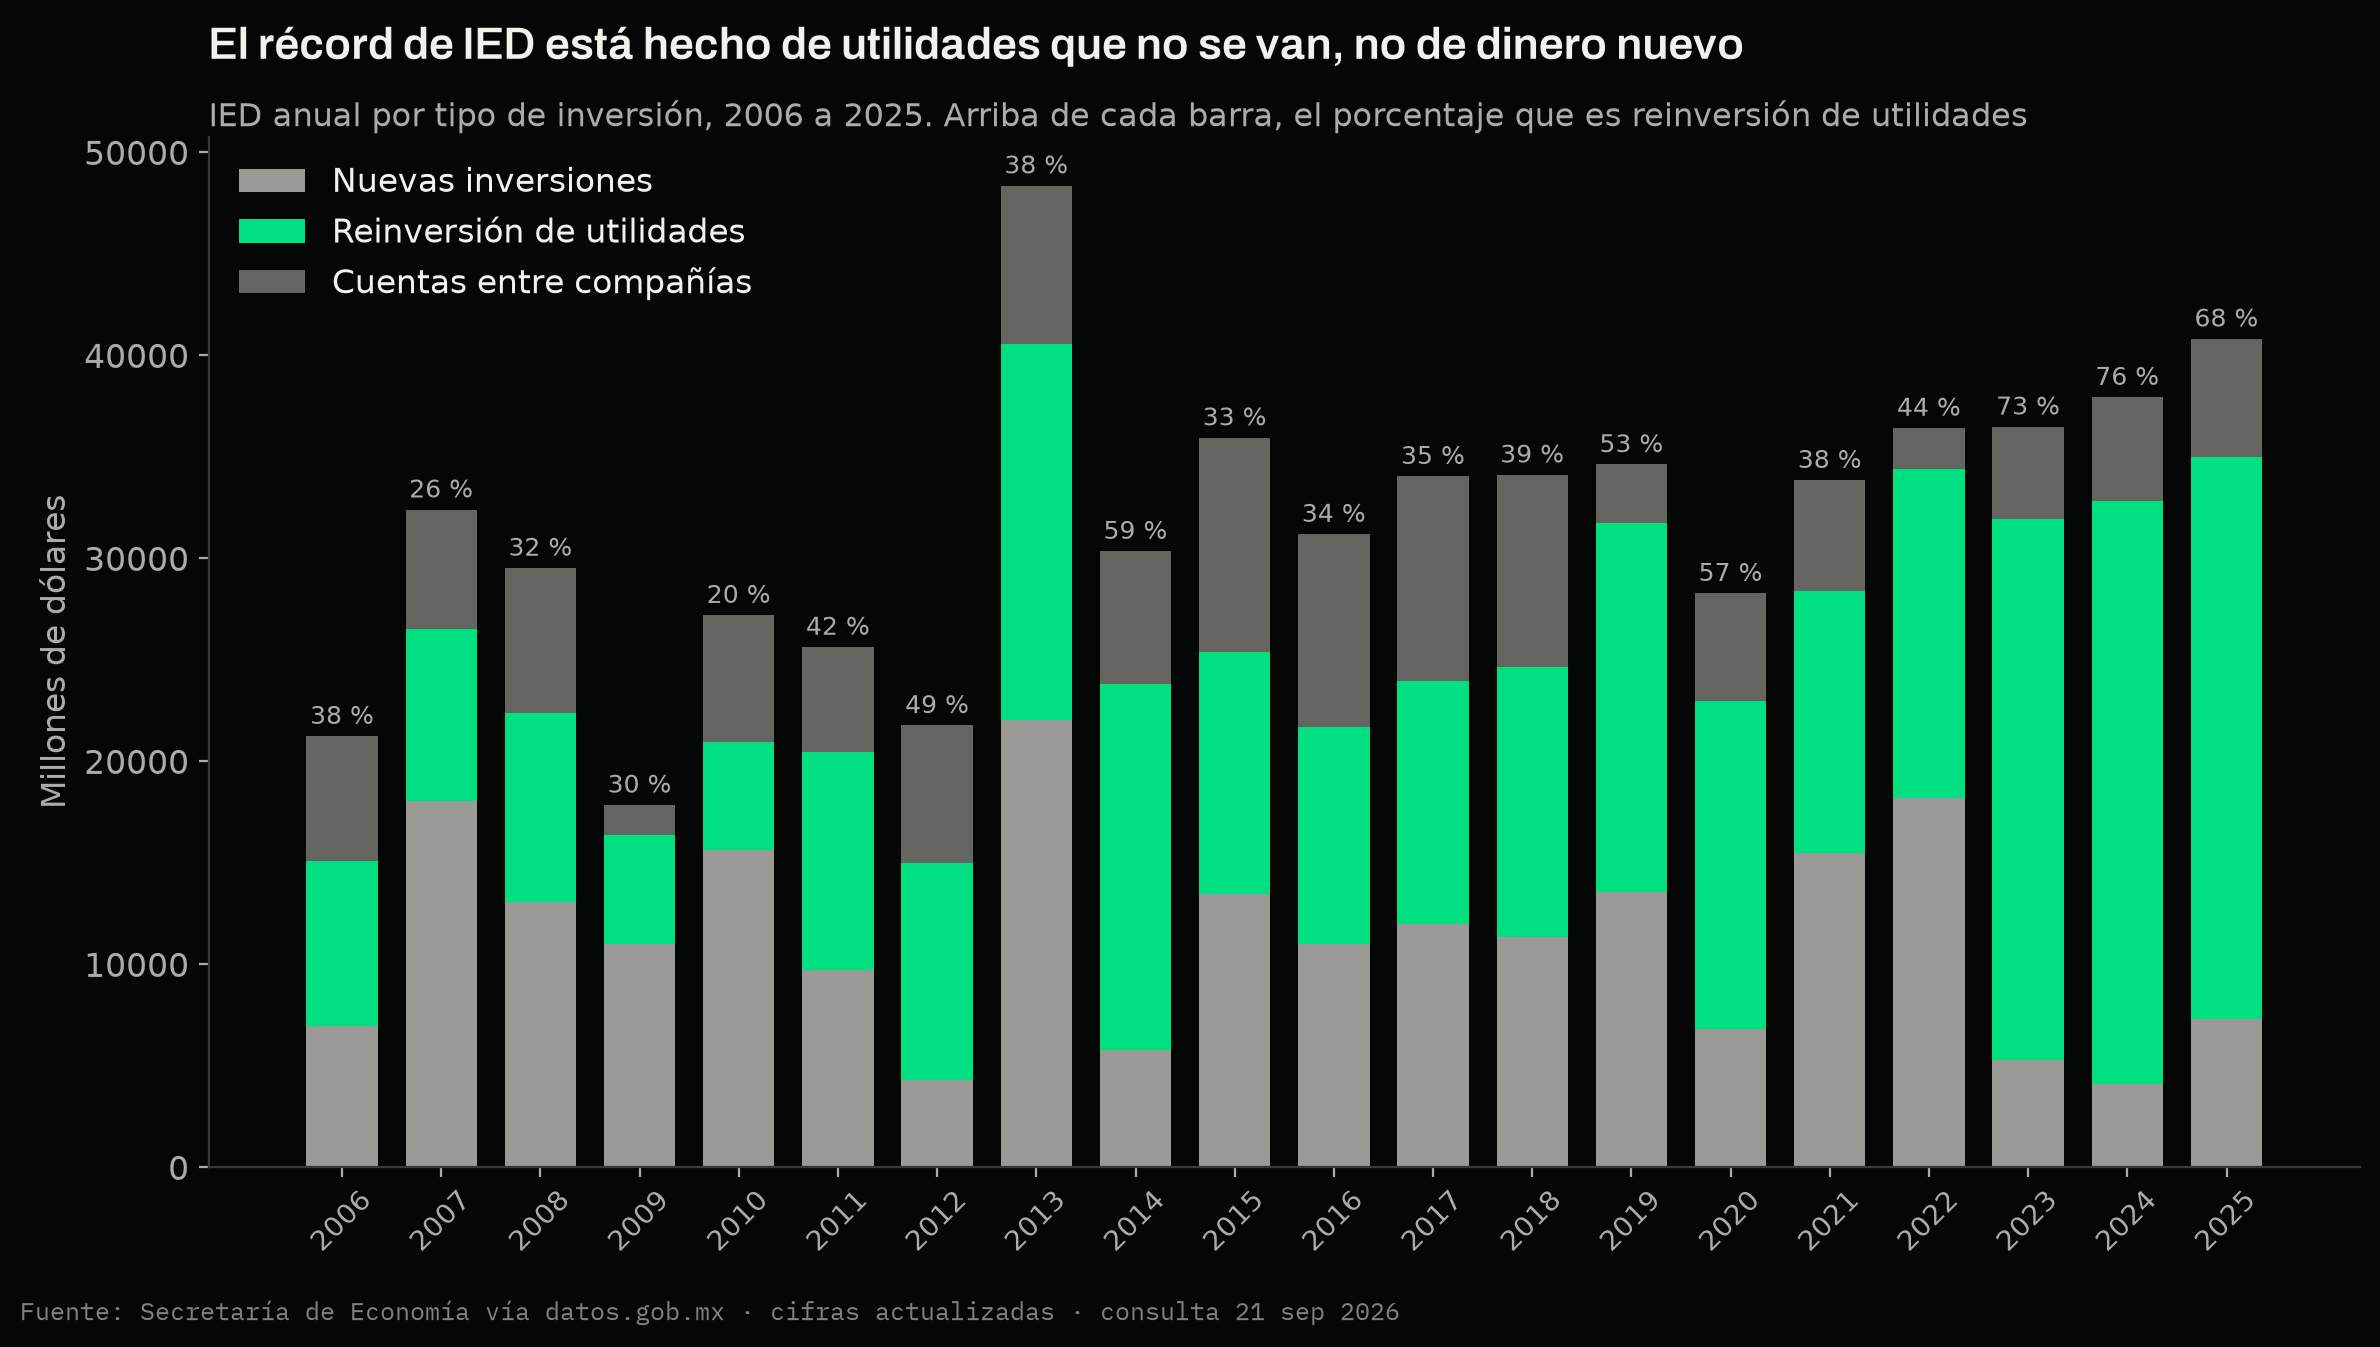

In [6]:
orden = ["Nuevas inversiones", "Reinversión de utilidades", "Cuentas entre compañías"]
col = {"Nuevas inversiones": PALETA["neutro_claro"], "Reinversión de utilidades": PALETA["acento"], "Cuentas entre compañías": PALETA["neutro"]}
fig, ax = plt.subplots()
abajo = pd.Series(0.0, index=partes.index)
for c in orden:
    ax.bar(partes.index, partes[c], bottom=abajo, color=col[c], label=c, width=0.72)
    abajo = abajo + partes[c].fillna(0)
for anio, valor in anual_tipo["Total general"].items():
    ax.text(anio, valor + 600, f"{pct.loc[anio, 'Reinversión de utilidades']:.0f} %", ha="center", fontsize=9, color=PALETA["tenue"])
ax.set_ylabel("Millones de dólares")
ax.set_xticks(list(partes.index))
ax.tick_params(axis="x", labelsize=10, rotation=45)
titulo(ax, "El récord de IED está hecho de utilidades que no se van, no de dinero nuevo")
ax.text(0, 1.01, "IED anual por tipo de inversión, 2006 a 2025. Arriba de cada barra, el porcentaje que es reinversión de utilidades",
        transform=ax.transAxes, fontsize=11.5, color=PALETA["tenue"])
ax.legend(loc="upper left")
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 2. La capital absorbe y el mapa se encoge

Dos lecturas de la misma tabla por estado: cuánto se lleva la Ciudad de México y cuántos estados hacen falta para sumar el 80 % de la inversión.

In [7]:
cdmx = participacion.loc["Ciudad de México"]
print(f"CDMX: promedio 2006-2018 = {cdmx.loc[2006:2018].mean():.1f} %, 2024 = {cdmx[2024]:.1f} %, {ULTIMO} = {cdmx[ULTIMO]:.1f} %")
print(f"Estados para el 80 %: promedio 2006-2018 = {n80.loc[2006:2018].mean():.1f}, 2019 = {n80[2019]}, 2024 = {n80[2024]}, {ULTIMO} = {n80[ULTIMO]}")
pd.DataFrame({"CDMX %": cdmx.round(1), "estados para 80 %": n80}).T

CDMX: promedio 2006-2018 = 19.7 %, 2024 = 40.9 %, 2025 = 52.9 %
Estados para el 80 %: promedio 2006-2018 = 12.8, 2019 = 13, 2024 = 10, 2025 = 6


anio,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CDMX %,26.7,21.4,26.2,29.4,14.9,29.3,6.1,12.1,20.2,16.4,21.6,15.1,17.1,25.4,25.0,21.2,30.4,31.2,40.9,52.9
estados para 80 %,11.0,13.0,12.0,12.0,12.0,12.0,15.0,15.0,13.0,13.0,12.0,14.0,13.0,13.0,14.0,14.0,11.0,11.0,10.0,6.0


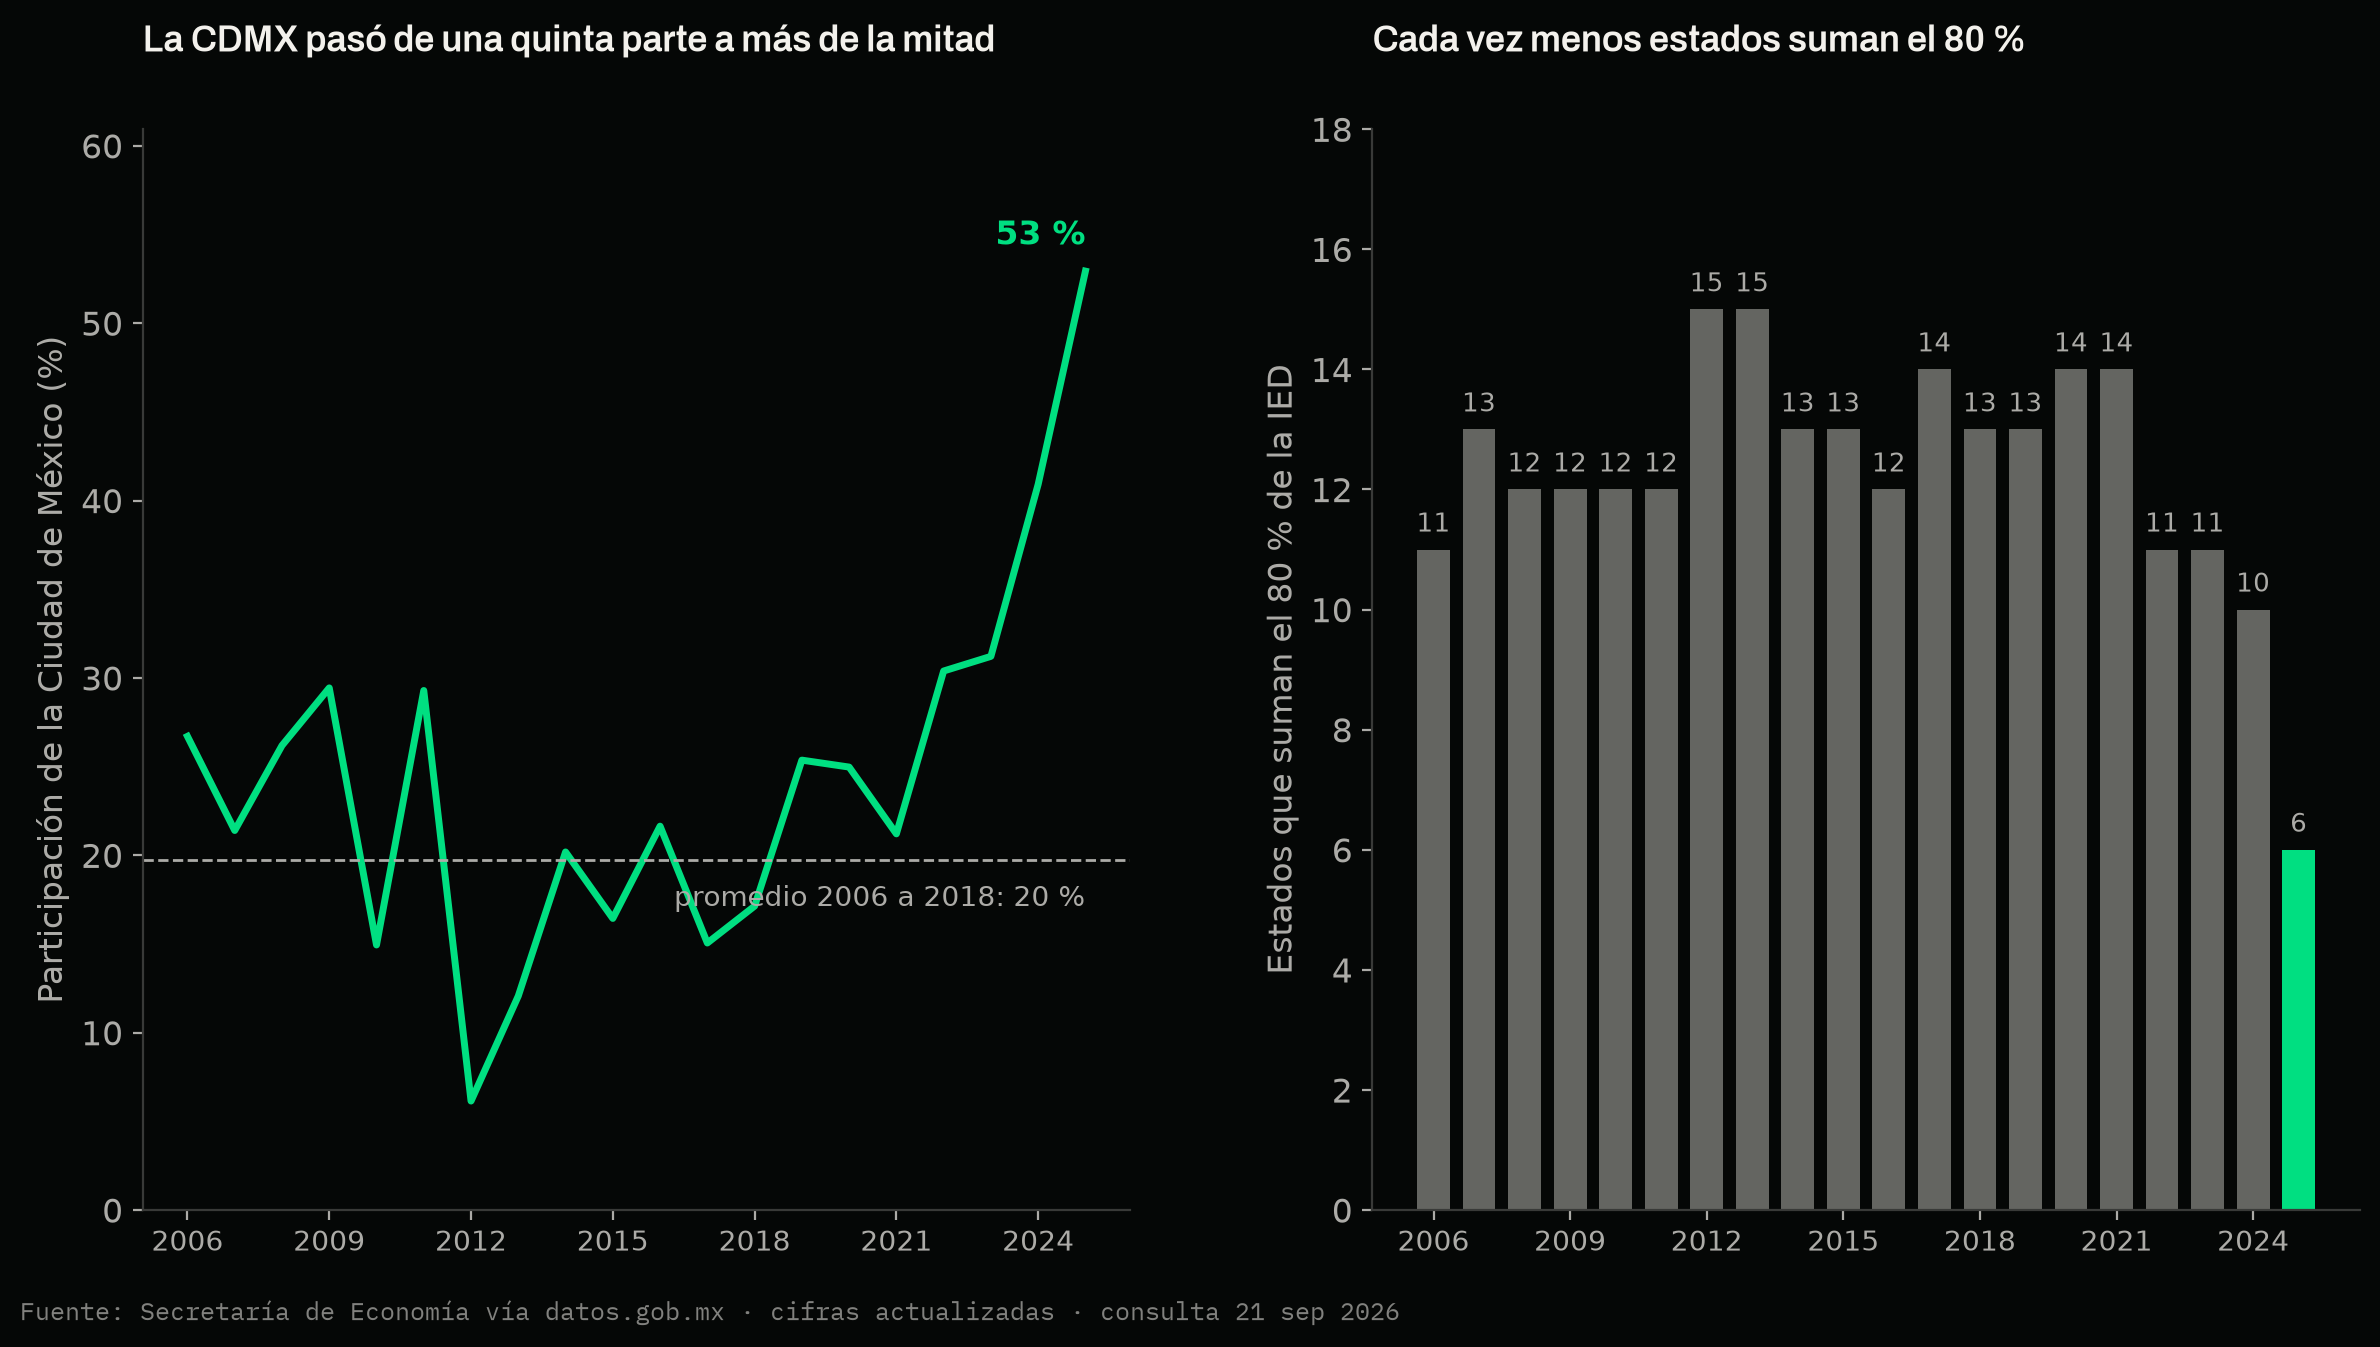

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75))
a1.plot(cdmx.index, cdmx.values, color=PALETA["acento"], linewidth=2.5)
a1.axhline(cdmx.loc[2006:2018].mean(), color=PALETA["tenue"], linestyle="--", linewidth=1)
a1.text(ULTIMO, cdmx.loc[2006:2018].mean() - 2.6, f"promedio 2006 a 2018: {cdmx.loc[2006:2018].mean():.0f} %", ha="right", fontsize=10, color=PALETA["tenue"])
a1.text(ULTIMO, cdmx[ULTIMO] + 1.5, f"{cdmx[ULTIMO]:.0f} %", ha="right", fontsize=12, color=PALETA["acento"], fontweight="bold")
a1.set_ylim(0, max(60, cdmx.max() + 8))
a1.set_ylabel("Participación de la Ciudad de México (%)")
titulo(a1, "La CDMX pasó de una quinta parte a más de la mitad", 13)
colores = [PALETA["acento"] if a == ULTIMO else PALETA["neutro"] for a in n80.index]
a2.bar(n80.index, n80.values, color=colores, width=0.72)
for a, v in n80.items():
    a2.text(a, v + 0.3, str(v), ha="center", fontsize=9.5, color=PALETA["tenue"])
a2.set_ylabel("Estados que suman el 80 % de la IED")
a2.set_ylim(0, n80.max() + 3)
titulo(a2, "Cada vez menos estados suman el 80 %", 13)
for a in (a1, a2):
    a.set_xticks(list(range(2006, ULTIMO + 1, 3)))
    a.tick_params(axis="x", labelsize=10)
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1), w_pad=4)
plt.show()

## 3. De dónde viene: Estados Unidos manda, China casi no aparece

País de origen según el inversionista final (criterio OCDE), no según el vehículo por el que entra el dinero. Las celdas confidenciales quedan fuera de la suma de países, no del total.

In [9]:
origen = leer("act_ti_origen")
anual_pais = origen[origen.trimestre == 4].pivot(index="pais_origen", columns="anio", values="ied_acumulado_mdd")
total_pais = anual_pais.loc["Total general"]
share = 100 * anual_pais.drop(index="Total general") / total_pais
eeuu = share.loc["Estados Unidos de América"]
china = share.loc["China, República Popular de"]
print(f"Estados Unidos: {ULTIMO} = {eeuu[ULTIMO]:.1f} %, mínimo {eeuu.min():.1f} % ({eeuu.idxmin()}), máximo {eeuu.max():.1f} % ({eeuu.idxmax()})")
print(f"China: máximo {china.max():.1f} % en {china.idxmax()}, {ULTIMO} = {china[ULTIMO]:.1f} %")
top5 = share[ULTIMO].dropna().sort_values(ascending=False).head(5)
top5.round(1)

Estados Unidos: 2025 = 39.1 %, mínimo 31.9 % (2020), máximo 63.5 % (2006)
China: máximo 2.4 % en 2024, 2025 = 1.4 %


pais_origen
Estados Unidos de América    39.1
España                        8.6
Canadá                        8.5
Japón                         5.7
Suiza                         4.9
Name: 2025, dtype: float64

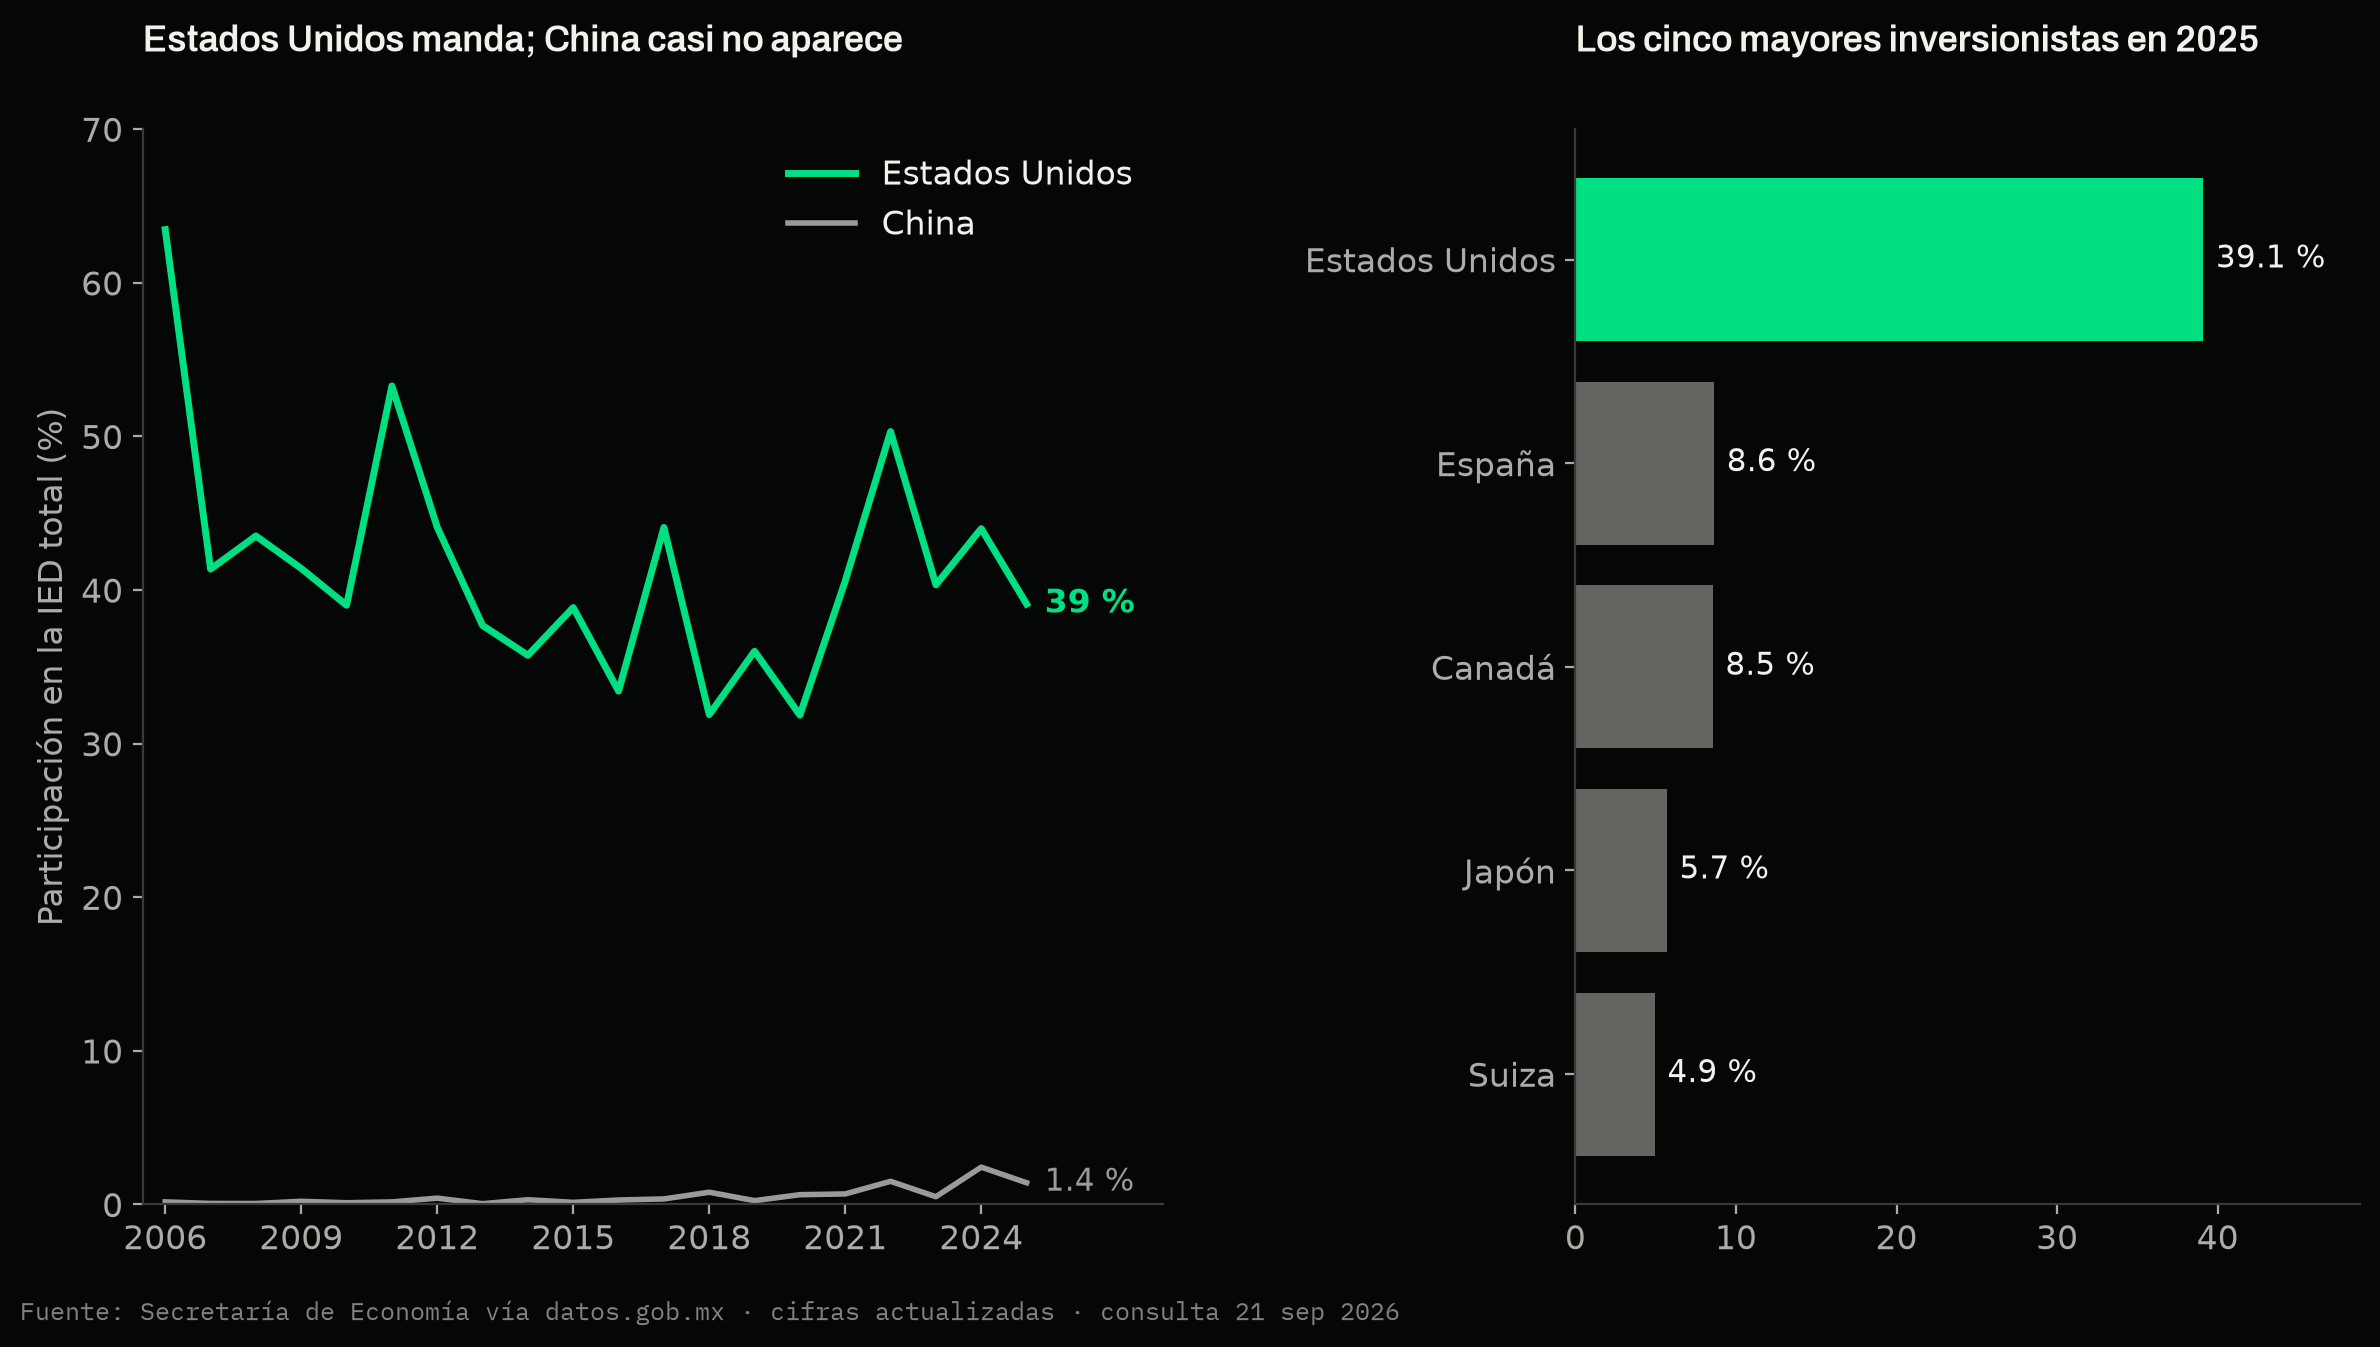

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75), gridspec_kw={"width_ratios": [1.3, 1]})
a1.plot(eeuu.index, eeuu.values, color=PALETA["acento"], linewidth=2.5, label="Estados Unidos")
a1.plot(china.index, china.values, color=PALETA["neutro_claro"], linewidth=2, label="China")
a1.text(ULTIMO + 0.4, eeuu[ULTIMO], f"{eeuu[ULTIMO]:.0f} %", va="center", fontsize=12, color=PALETA["acento"], fontweight="bold")
a1.text(ULTIMO + 0.4, china[ULTIMO], f"{china[ULTIMO]:.1f} %", va="center", fontsize=11, color=PALETA["neutro_claro"])
a1.set_ylim(0, 70)
a1.set_xlim(2005.5, ULTIMO + 3)
a1.set_xticks(list(range(2006, ULTIMO + 1, 3)))
a1.set_ylabel("Participación en la IED total (%)")
titulo(a1, "Estados Unidos manda; China casi no aparece", 13)
a1.legend(loc="upper right")
t5 = top5.iloc[::-1]
a2.barh(t5.index.str.replace("Estados Unidos de América", "Estados Unidos"), t5.values,
        color=[PALETA["acento"] if "Estados Unidos" in p else PALETA["neutro"] for p in t5.index])
for i, v in enumerate(t5.values):
    a2.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=11)
a2.set_xlim(0, t5.max() * 1.25)
titulo(a2, f"Los cinco mayores inversionistas en {ULTIMO}", 13)
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1), w_pad=4)
plt.show()

## 4. A dónde va el dinero nuevo

Si se aparta la reinversión y se mira solo la inversión nueva de los últimos cinco años, el mapa cambia de forma: aparecen destinos turísticos y el norte industrial pesa menos de lo que sugiere el discurso.

In [11]:
ef = leer("act_ef_tipodeinv")
nuevas = ef[(ef.tipo_inversion == "Nuevas inversiones") & (ef.entidad_federativa != "Total general") & ef.anio.between(ULTIMO - 4, ULTIMO)]
nuevas_estado = nuevas.groupby("entidad_federativa")["flujo_mdd"].sum().sort_values(ascending=False)
nuevas_pct = 100 * nuevas_estado / nuevas_estado.sum()
print(f"Nuevas inversiones {ULTIMO - 4}-{ULTIMO}: {nuevas_estado.sum():,.0f} mdd en total")
pd.DataFrame({"mdd": nuevas_estado.round(0), "%": nuevas_pct.round(1)}).head(10)

Nuevas inversiones 2021-2025: 50,384 mdd en total


,mdd,%
entidad_federativa,,
Ciudad de México,15881.0,31.5
Baja California Sur,5185.0,10.3
Nuevo León,4260.0,8.5
Jalisco,2828.0,5.6
Quintana Roo,2633.0,5.2
Baja California,2207.0,4.4
Guanajuato,1828.0,3.6
Coahuila,1413.0,2.8
Tamaulipas,1412.0,2.8


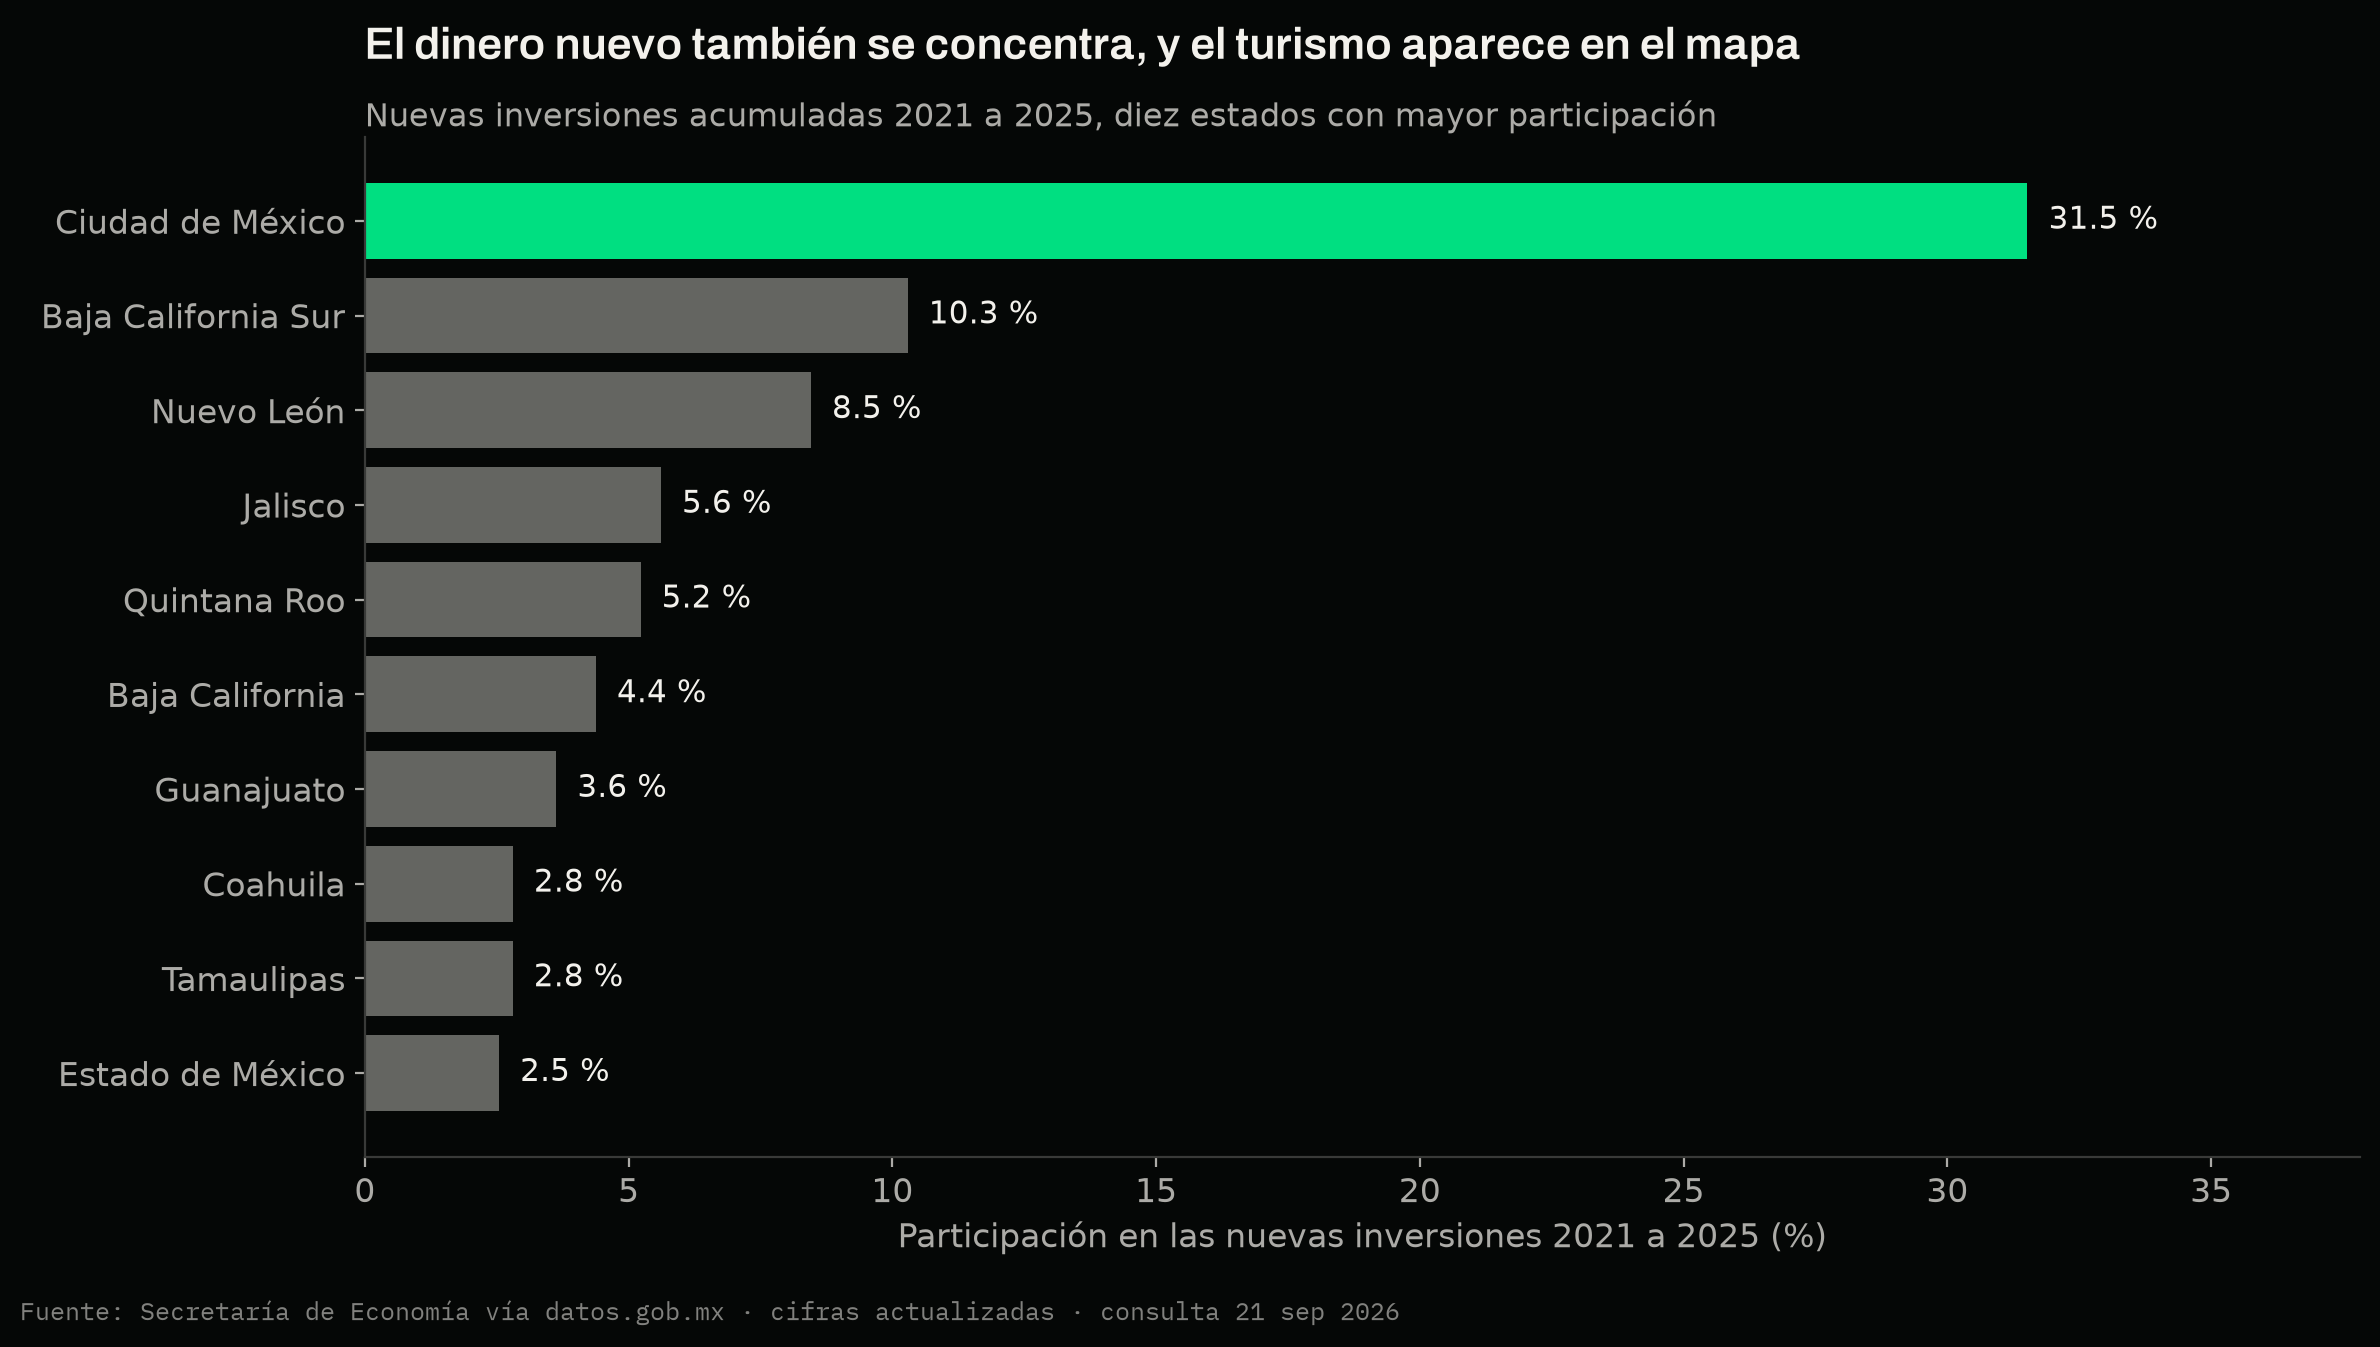

In [12]:
t10 = nuevas_pct.head(10).iloc[::-1]
fig, ax = plt.subplots()
ax.barh(t10.index, t10.values, color=[PALETA["acento"] if e == "Ciudad de México" else PALETA["neutro"] for e in t10.index])
for i, v in enumerate(t10.values):
    ax.text(v + 0.4, i, f"{v:.1f} %", va="center", fontsize=11)
ax.set_xlim(0, t10.max() * 1.2)
ax.set_xlabel(f"Participación en las nuevas inversiones {ULTIMO - 4} a {ULTIMO} (%)")
titulo(ax, "El dinero nuevo también se concentra, y el turismo aparece en el mapa")
ax.text(0, 1.01, f"Nuevas inversiones acumuladas {ULTIMO - 4} a {ULTIMO}, diez estados con mayor participación",
        transform=ax.transAxes, fontsize=11.5, color=PALETA["tenue"])
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 5. Advertencias antes de citar estas cifras

- **Domicilio fiscal, no planta.** La Secretaría de Economía asigna cada flujo al estado donde la empresa receptora tiene su domicilio fiscal. Una armadora en Coahuila con corporativo en la Ciudad de México cuenta para la capital. Parte de la concentración de la sección 2 es eso.
- **Inversionista final.** El país de origen sigue el criterio del inversionista final de la OCDE. Una filial holandesa de un grupo estadounidense cuenta como Estados Unidos, no como Países Bajos.
- **Confidenciales y revisiones.** Las celdas que identificarían a una empresa no se publican, y la Secretaría revisa cifras hacia atrás. Todo lo anterior usa cifras actualizadas al 28 de agosto de 2026; el notebook 01 concilia las originales con los boletines.
- **2026 sigue igual.** El datastore cierra en el primer trimestre de 2026. El boletín de la Secretaría del 24 de agosto de 2026 reporta 34,968 millones de dólares en el primer semestre, 88.5 % de ellos reinversión de utilidades; Ciudad de México con 48.2 % y Estados Unidos con 48.2 %. Esas cuatro cifras vienen del boletín, no de estas tablas.